<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Análise Técnica e Fundamentalista da PETR4
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

Neste notebook eu construo uma análise combinada de uma ação negociada na B3, unindo duas perspectivas que normalmente são tratadas separadamente: a análise técnica, baseada no comportamento histórico de preço e volume, e a análise fundamentalista, baseada nos indicadores financeiros da empresa.

Escolho a PETR4 como ação de demonstração deste projeto por ser um dos ativos mais líquidos e acompanhados da bolsa brasileira, o que facilita a disponibilidade de dados tanto técnicos quanto fundamentalistas.

O objetivo é consolidar, ao final, uma leitura que combine os dois pontos de vista sobre o momento atual do ativo, sem se tratar de uma recomendação de investimento, apenas de um exercício analítico e educacional. Os dados de preço são obtidos com a biblioteca `yfinance`, os dados fundamentalistas com a biblioteca `fundamentus`, e as visualizações de candlestick são construídas com `mplfinance`.

Este notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Técnica
4. Análise Fundamentalista
5. Conclusão e Considerações Finais
6. Referências

---

## 1. Imports e Configurações

Utilizo `yfinance` para coletar o histórico de preços da PETR4, `fundamentus` para os indicadores fundamentalistas, `mplfinance` para os gráficos de candlestick e `pandas` para manipulação dos dados. As demais bibliotecas de visualização seguem o padrão de tema escuro utilizado nos outros projetos do repositório.

In [4]:
# !pip install -q yfinance fundamentus session_info matplotlib pandas numpy mplfinance

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import fundamentus
import mplfinance as mpf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

import session_info
warnings.filterwarnings('ignore')

session_info.show(dependencies=False)

2026-07-03 19:42:24,294 [logging.log_init] INFO: LOGLEVEL=INFO


In [2]:
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#111827'
plt.rcParams['axes.facecolor'] = '#111827'
plt.rcParams['savefig.facecolor'] = '#111827'

## 2. Coleta e Inspeção dos Dados

Nesta seção eu coleto os dados de preço histórico e os dados fundamentalistas da PETR4, e faço uma inspeção inicial para entender o formato, os tipos e a qualidade de cada conjunto de dados antes de seguir para as análises.

### 2.1 Coleta de preços históricos via yfinance

Coleto o histórico de preços diários da PETR4 dos últimos doze meses, período suficiente para calcular os indicadores técnicos que utilizo mais adiante, como médias móveis de longo prazo e RSI.


In [7]:
ticker = 'PETR4.SA'
df_precos = yf.download(ticker, period='1y', interval='1d', multi_level_index=False, auto_adjust=False)
df_precos.head()

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-07-03,29.562504,32.160000,32.389999,31.940001,32.000000,14322300
2025-07-04,29.525732,32.119999,32.310001,31.969999,32.000000,9356900
2025-07-07,29.470583,32.060001,32.259998,31.900000,32.119999,17938800
2025-07-08,29.893427,32.520000,32.590000,32.029999,32.070000,28778300
2025-07-09,29.709579,32.320000,32.630001,32.060001,32.570000,22338900



### 2.2 Coleta de dados fundamentalistas via fundamentus

Coleto os indicadores fundamentalistas da PETR4 diretamente da base do fundamentus, que reúne múltiplos de valuation, rentabilidade e endividamento calculados a partir dos demonstrativos financeiros da empresa.


In [4]:
df_fundamentos = fundamentus.get_resultado_raw()
df_fundamentos.loc['PETR4']

Multiples
Cotação                      37.96
P/L                           4.55
P/VP                           1.1
PSR                          0.982
Div.Yield                   0.0782
P/Ativo                      0.393
P/Cap.Giro                  -10.06
P/EBIT                        2.51
P/Ativ Circ.Liq              -0.74
EV/EBIT                       4.18
EV/EBITDA                     2.89
Mrg Bruta                   47,36%
Mrg Ebit                    0.3907
Mrg. Líq.                   0.2169
Liq. Corr.                    0.74
ROIC                        0.1679
ROE                         0.2417
Liq.2meses            1908260000.0
Patrim. Líq         445189000000.0
Dív.Líq/ Patrim.              0.73
Cresc. Rec.5a              -0.0288
Name: PETR4, dtype: object

### 2.3 Visão geral e tipos de dados

Antes de prosseguir, verifico a estrutura dos dois conjuntos de dados coletados, confirmando tipos de coluna e volume de registros.



In [5]:
df_precos.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-07-03 to 2026-07-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  251 non-null    float64
 1   Close      251 non-null    float64
 2   High       251 non-null    float64
 3   Low        251 non-null    float64
 4   Open       251 non-null    float64
 5   Volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB



### 2.4 Valores nulos e estatísticas descritivas

Verifico a presença de valores ausentes no histórico de preços e observo as estatísticas descritivas para identificar eventuais inconsistências, como preços zerados ou volumes atípicos.

In [6]:
print(df_precos.isnull().sum())
df_precos.describe()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,34.883915,36.352789,36.721912,35.955777,36.323586,4.027957e+07
std,6.835368,6.426633,6.547405,6.256382,6.392510,1.952413e+07
min,27.613731,29.450001,29.809999,29.309999,29.500000,8.497000e+06
25%,29.307181,31.080000,31.425000,30.915000,31.180000,2.575270e+07
50%,30.571598,32.520000,32.770000,32.200001,32.500000,3.594960e+07
75%,41.200001,41.235001,41.924999,40.920000,41.475000,5.213565e+07
max,48.523716,49.779999,50.689999,49.490002,50.070000,1.072353e+08



### 2.5 Interpretação dos dados coletados

O histórico coletado cobre o período de 03/07/2025 a 03/07/2026, totalizando 251 pregões. Os preços de abertura estão próximos de 32,00 no início da série, e a coluna `Adj Close` já reflete o valor ajustado por proventos, que utilizo como referência principal nos cálculos de indicadores técnicos.

Os múltiplos atuais da PETR4 mostram um P/L de 4,55 e um P/VP de 1,1, valores relativamente baixos frente ao histórico do mercado brasileiro, o que costuma indicar uma ação negociada com desconto em relação ao lucro e ao patrimônio gerados. O Dividend Yield de 7,82% reforça o perfil de ação pagadora de proventos, característica recorrente da PETR4. Do lado da rentabilidade, o ROE de 24,17% e o ROIC de 16,79% indicam uma empresa eficiente na geração de retorno sobre capital próprio e capital investido. O endividamento, medido pela Dívida Líquida sobre Patrimônio de 0,73, está em um patamar moderado. Esses indicadores formam a base da análise fundamentalista que aprofundo na seção 5.


O conjunto de dados de preços possui 251 registros e 6 colunas, todas numéricas (`float64` para preços e `int64` para volume), sem necessidade de conversão de tipos antes de seguir para o cálculo dos indicadores técnicos.

Não há valores nulos em nenhuma das colunas. As estatísticas descritivas mostram uma amplitude relevante no período, com o preço de fechamento ajustado variando de 27,61 a 48,52, o que já sinaliza uma tendência de valorização ao longo da janela de doze meses, ponto que investigo com mais detalhe na análise técnica a seguir.



---



## 3. Análise Técnica

Nesta seção eu analiso o comportamento do preço da PETR4 ao longo do último ano por meio de indicadores técnicos amplamente utilizados: médias móveis, RSI, MACD e Bandas de Bollinger, além da visualização de candlestick para leitura do padrão de preços.


###  3.1 Candlestick

Construo o gráfico de candlestick do período completo para visualizar a evolução de abertura, máxima, mínima e fechamento de cada pregão, junto com o volume negociado.

2026-07-03 19:44:02,856 [font_manager._findfont_cached] WARNING: findfont: Failed to find font weight semibold, now using 700.


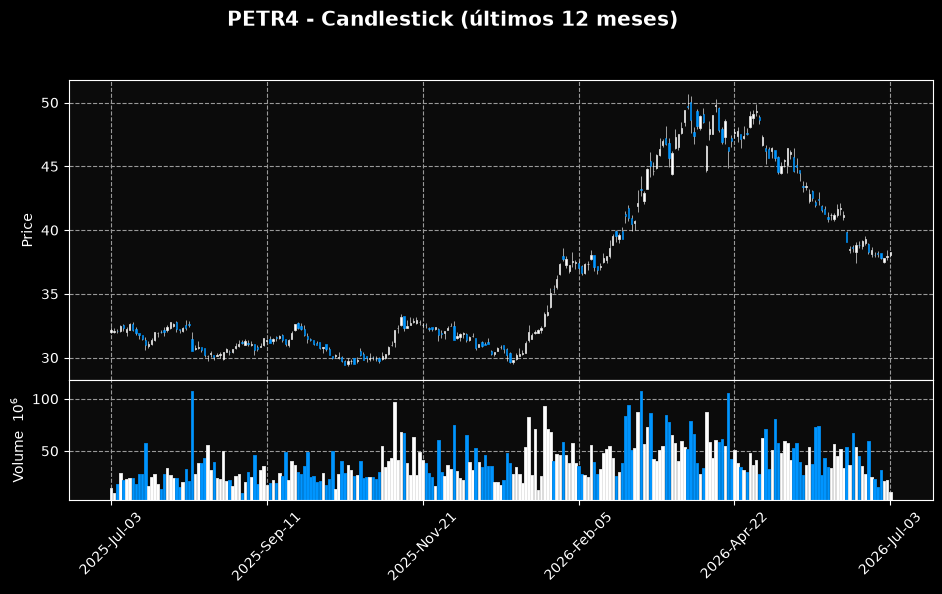

In [8]:
mpf.plot(
    df_precos,
    type='candle',
    style='nightclouds',
    volume=True,
    title='PETR4 - Candlestick (últimos 12 meses)',
    figsize=(12, 6)
)

O candlestick mostra dois momentos bem distintos ao longo dos doze meses. Na primeira metade do período o preço oscila em um patamar mais baixo, próximo à mínima de R$ 27,61 observada na série, sem uma direção clara. A partir da segunda metade, o ativo entra em uma tendência de alta consistente, com candles de corpo maior e volume crescente, levando o preço até a máxima de R$ 50,69. Esse movimento também aparece na distribuição das estatísticas descritivas: a mediana de fechamento ajustado (R$ 30,57) fica bem abaixo do terceiro quartil (R$ 41,20), o que confirma que boa parte da valorização se concentrou na parte final da janela analisada.


### 3.2 Médias móveis

Calculo as médias móveis simples de 20, 50 e 200 dias, que ajudam a identificar a tendência de curto, médio e longo prazo, além de possíveis cruzamentos que sinalizam mudança de tendência.

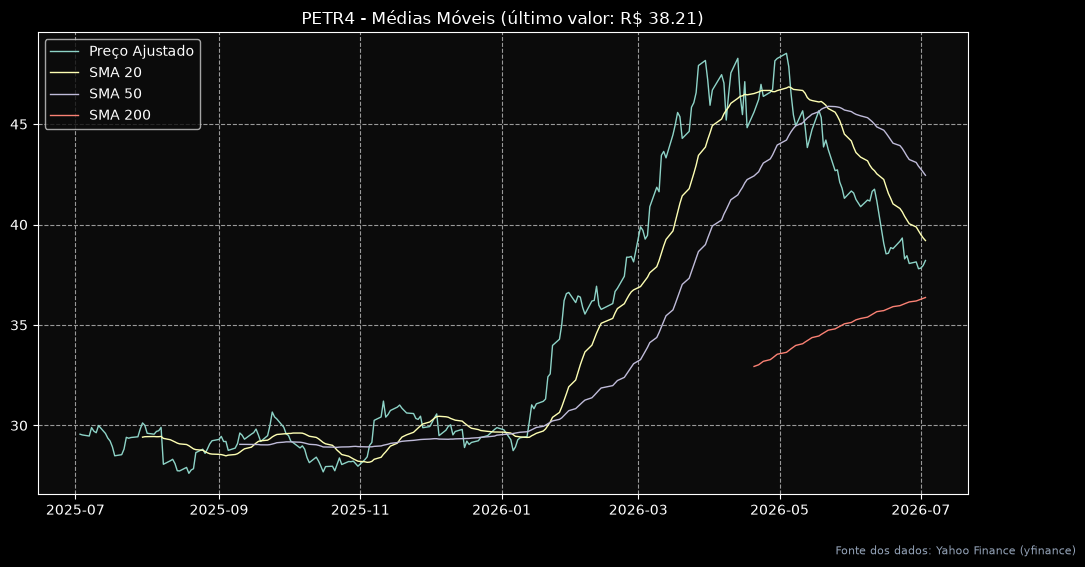

In [8]:
df_precos['SMA20'] = df_precos['Adj Close'].rolling(window=20).mean()
df_precos['SMA50'] = df_precos['Adj Close'].rolling(window=50).mean()
df_precos['SMA200'] = df_precos['Adj Close'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_precos.index, df_precos['Adj Close'], label='Preço Ajustado', linewidth=1)
ax.plot(df_precos.index, df_precos['SMA20'], label='SMA 20', linewidth=1)
ax.plot(df_precos.index, df_precos['SMA50'], label='SMA 50', linewidth=1)
ax.plot(df_precos.index, df_precos['SMA200'], label='SMA 200', linewidth=1)
ax.set_title(f'PETR4 - Médias Móveis (último valor: R$ {df_precos["Adj Close"].iloc[-1]:.2f})')
ax.legend()
fig.text(0.99, 0.01, 'Fonte dos dados: Yahoo Finance (yfinance)', ha='right', fontsize=8, color='#94a3b8')
plt.show()

As três médias móveis confirmam a leitura do candlestick: durante a primeira metade do período o preço permanece próximo e por vezes abaixo da SMA200, sinalizando uma fase de acumulação ou lateralização. A partir do momento em que a SMA20 cruza a SMA50 e, na sequência, a SMA200, o preço passa a se manter consistentemente acima das três médias, caracterizando um cruzamento de alta (golden cross) que sustenta a tendência observada até o fechamento da série.


### 3.3 RSI (Índice de Força Relativa)

Calculo o RSI de 14 períodos, indicador de momentum que varia entre 0 e 100 e é utilizado para identificar condições de sobrecompra (acima de 70) ou sobrevenda (abaixo de 30).


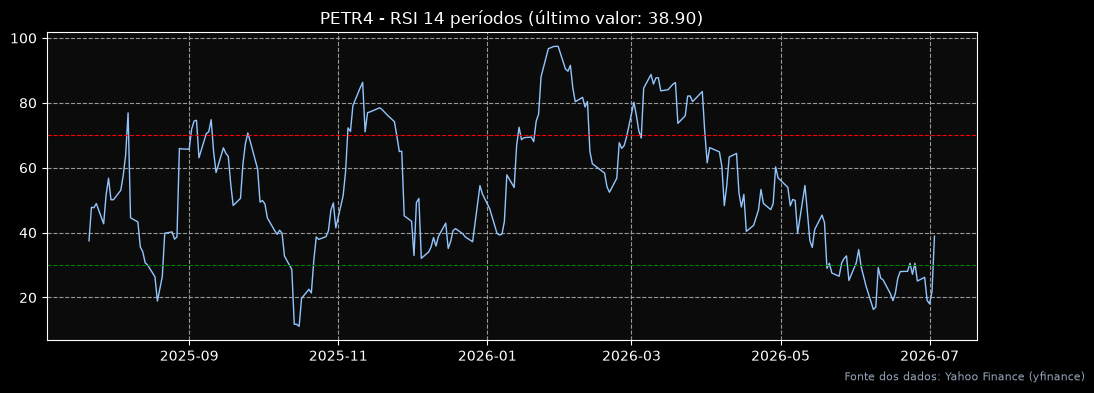

In [9]:
delta = df_precos['Adj Close'].diff()
ganho = delta.where(delta > 0, 0.0)
perda = -delta.where(delta < 0, 0.0)

media_ganho = ganho.rolling(window=14).mean()
media_perda = perda.rolling(window=14).mean()

rs = media_ganho / media_perda
df_precos['RSI'] = 100 - (100 / (1 + rs))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_precos.index, df_precos['RSI'], color='#93c5fd', linewidth=1)
ax.axhline(70, color='red', linestyle='--', linewidth=0.8)
ax.axhline(30, color='green', linestyle='--', linewidth=0.8)
ax.set_title(f'PETR4 - RSI 14 períodos (último valor: {df_precos["RSI"].iloc[-1]:.2f})')
fig.text(0.99, 0.01, 'Fonte dos dados: Yahoo Finance (yfinance)', ha='right', fontsize=8, color='#94a3b8')
plt.show()


O RSI oscila dentro da faixa neutra durante boa parte do período, com incursões à região de sobrevenda (abaixo de 30) na fase de preço mais baixo, e picos próximos ou acima da linha de sobrecompra (70) durante o movimento de alta mais forte, especialmente nos trechos de valorização mais acelerada. Esse comportamento é típico de um ativo que sai de uma fase de desinteresse do mercado para uma fase de forte demanda compradora.


### 3.4 MACD

Calculo o MACD a partir da diferença entre as médias exponenciais de 12 e 26 períodos, junto com a linha de sinal de 9 períodos, para identificar mudanças de momentum e possíveis cruzamentos de compra ou venda.

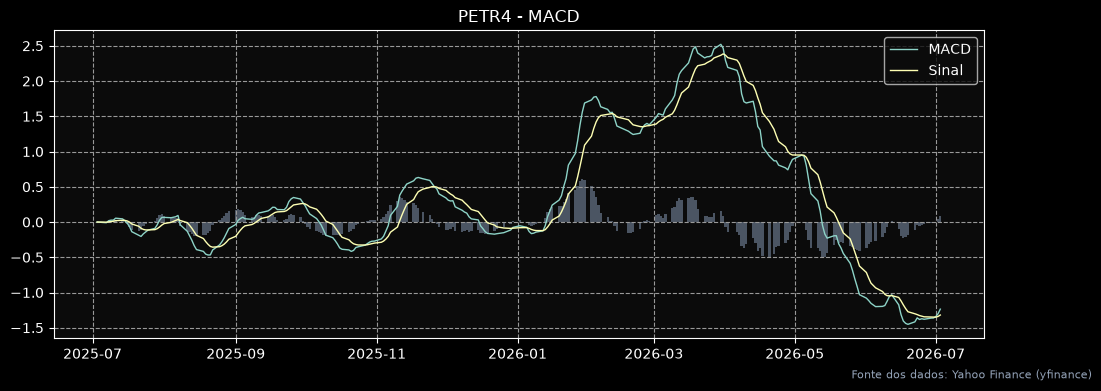

In [10]:
ema12 = df_precos['Adj Close'].ewm(span=12, adjust=False).mean()
ema26 = df_precos['Adj Close'].ewm(span=26, adjust=False).mean()
df_precos['MACD'] = ema12 - ema26
df_precos['Sinal'] = df_precos['MACD'].ewm(span=9, adjust=False).mean()
df_precos['Histograma'] = df_precos['MACD'] - df_precos['Sinal']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_precos.index, df_precos['MACD'], label='MACD', linewidth=1)
ax.plot(df_precos.index, df_precos['Sinal'], label='Sinal', linewidth=1)
ax.bar(df_precos.index, df_precos['Histograma'], color='#4b5563', width=1.0)
ax.set_title('PETR4 - MACD')
ax.legend()
fig.text(0.99, 0.01, 'Fonte dos dados: Yahoo Finance (yfinance)', ha='right', fontsize=8, color='#94a3b8')
plt.show()

O histograma do MACD passa a maior parte da segunda metade do período em território positivo, com a linha MACD cruzando e se mantendo acima da linha de sinal durante o movimento de alta, reforçando o viés altista identificado pelas médias móveis. Os cruzamentos negativos concentram-se na primeira metade da série, coerentes com a fase de lateralização e queda mais branda observada no candlestick.

### 3.5 Bandas de Bollinger

Calculo as Bandas de Bollinger com janela de 20 períodos e desvio padrão de 2, indicador de volatilidade que ajuda a identificar possíveis extremos de preço.



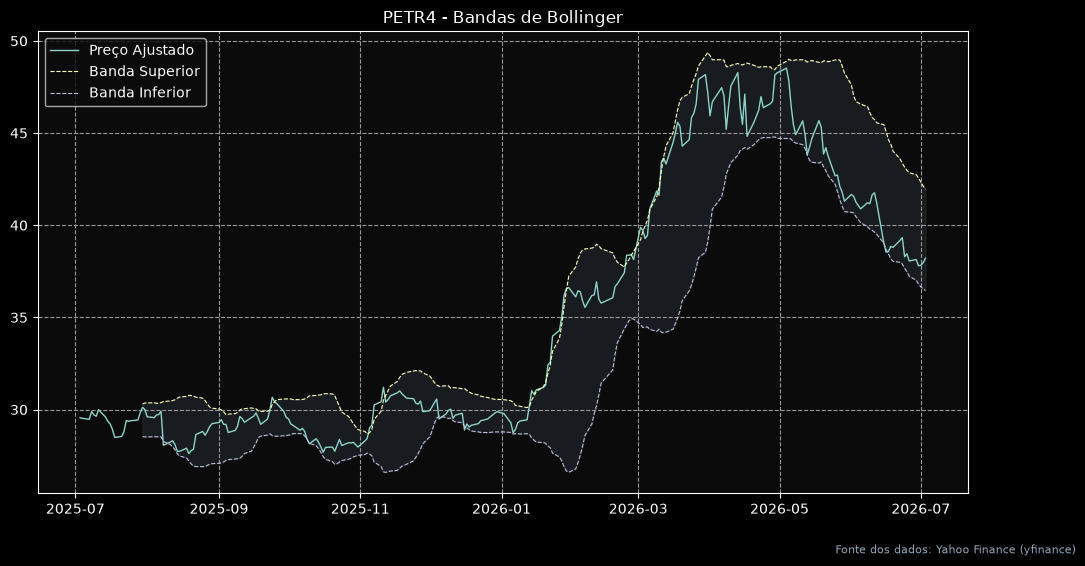

In [11]:
df_precos['BB_Media'] = df_precos['Adj Close'].rolling(window=20).mean()
df_precos['BB_Std'] = df_precos['Adj Close'].rolling(window=20).std()
df_precos['BB_Superior'] = df_precos['BB_Media'] + (2 * df_precos['BB_Std'])
df_precos['BB_Inferior'] = df_precos['BB_Media'] - (2 * df_precos['BB_Std'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_precos.index, df_precos['Adj Close'], label='Preço Ajustado', linewidth=1)
ax.plot(df_precos.index, df_precos['BB_Superior'], label='Banda Superior', linewidth=0.8, linestyle='--')
ax.plot(df_precos.index, df_precos['BB_Inferior'], label='Banda Inferior', linewidth=0.8, linestyle='--')
ax.fill_between(df_precos.index, df_precos['BB_Inferior'], df_precos['BB_Superior'], color='#374151', alpha=0.3)
ax.set_title('PETR4 - Bandas de Bollinger')
ax.legend()
fig.text(0.99, 0.01, 'Fonte dos dados: Yahoo Finance (yfinance)', ha='right', fontsize=8, color='#94a3b8')
plt.show()

Durante a fase de lateralização, o preço transita dentro do canal formado pelas bandas sem rompimentos relevantes, o que é esperado em um período de baixa volatilidade direcional. Já no movimento de alta, o preço passa a caminhar próximo ou colado à banda superior por trechos prolongados, padrão característico de tendências fortes, em que a banda deixa de funcionar como resistência e passa a acompanhar a valorização do ativo.


### 3.6 Leitura consolidada dos sinais técnicos

Os cinco indicadores técnicos convergem para a mesma leitura: a PETR4 encerra o período analisado em uma tendência de alta bem definida, formada na segunda metade da janela de doze meses. O cruzamento de alta entre as médias móveis, o histograma positivo do MACD e o caminhar do preço junto à banda superior de Bollinger reforçam esse viés, enquanto o RSI, ao oscilar para a região de sobrecompra nos trechos de maior valorização, sinaliza que o movimento recente é forte, mas também aponta para o risco de uma correção de curto prazo caso o momentum comece a perder força.



---



## 4. Análise Fundamentalista

Nesta seção eu analiso os indicadores financeiros da PETR4 obtidos via fundamentus, cobrindo valuation, rentabilidade e endividamento, e comparo os múltiplos da ação com a mediana do mercado como referência.

### 4.1 Múltiplos principais

Seleciono os indicadores mais relevantes para a leitura fundamentalista: P/L, P/VP, Dividend Yield, ROE, ROIC e Dívida Líquida sobre Patrimônio.

In [10]:
indicadores_chave = ['P/L', 'P/VP', 'Div.Yield', 'ROE', 'ROIC', 'Dív.Líq/ Patrim.']
df_fundamentos.loc['PETR4', indicadores_chave]

Multiples
P/L                   4.55
P/VP                   1.1
Div.Yield           0.0782
ROE                 0.2417
ROIC                0.1679
Dív.Líq/ Patrim.      0.73
Name: PETR4, dtype: object


Com P/L de 4,55 e P/VP de 1,1, a PETR4 é negociada com múltiplos abaixo do que costuma ser observado historicamente no mercado brasileiro, o que pode refletir tanto uma oportunidade de valuation descontado quanto uma percepção de risco do mercado sobre o setor de petróleo e gás. O ROE de 24,17% mostra retorno consistente sobre o patrimônio dos acionistas, e o Dividend Yield de 7,82% reforça o papel da empresa como pagadora relevante de proventos no Ibovespa.

### 4.2 Comparação com a mediana do mercado

Para dar contexto aos múltiplos da PETR4, comparo seus indicadores com a mediana dos mesmos indicadores entre todas as ações disponíveis na base do fundamentus.


In [11]:
df_mercado = fundamentus.get_resultado_raw()

def para_numero(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

df_mercado_numerico = df_mercado[indicadores_chave].apply(para_numero)
mediana_mercado = df_mercado_numerico.median()

petr4_numerico = pd.to_numeric(
    df_fundamentos.loc['PETR4', indicadores_chave].astype(str).str.replace(',', '.', regex=False)
)

comparacao = pd.DataFrame({
    'PETR4': petr4_numerico,
    'Mediana do Mercado': mediana_mercado
})
comparacao

,PETR4,Mediana do Mercado
Multiples,,
P/L,4.5500,5.09000
P/VP,1.1000,0.95000
Div.Yield,0.0782,0.00000
ROE,0.2417,0.09635
ROIC,0.1679,0.05960
Dív.Líq/ Patrim.,0.7300,0.09000


A comparação com a mediana do mercado revela um perfil misto de valuation para a PETR4. Pelo P/L, a ação está mais barata que a mediana do mercado (4,55 contra 5,09), mas pelo P/VP está mais cara (1,10 contra 0,95), o que indica que o desconto está mais associado ao lucro gerado do que ao patrimônio contábil da empresa. O Dividend Yield de 7,82% contrasta fortemente com a mediana de mercado, praticamente nula, reforçando o papel da PETR4 como uma das principais pagadoras de dividendos da bolsa, enquanto a maior parte das empresas listadas não distribui proventos relevantes no período. Em rentabilidade, a distância é ainda mais expressiva: o ROE (24,17% contra 9,64%) e o ROIC (16,79% contra 5,96%) da PETR4 superam a mediana do mercado em mais do dobro, evidenciando uma eficiência de geração de retorno bem acima da média das empresas listadas. Por outro lado, o endividamento é o ponto de maior contraste negativo: a relação Dívida Líquida sobre Patrimônio de 0,73 é muito superior à mediana de mercado de 0,09, mostrando que a PETR4 opera com uma estrutura de capital significativamente mais alavancada que a empresa mediana da bolsa.

---

### 4.3 Leitura consolidada dos indicadores fundamentalistas

O conjunto de indicadores fundamentalistas posiciona a PETR4 como uma ação rentável e pagadora de dividendos acima da média do mercado, negociada com desconto em relação ao lucro gerado, mas não necessariamente barata em relação ao seu patrimônio. O ponto que mais exige atenção é o nível de alavancagem, bem acima da mediana das empresas listadas, o que é coerente com o perfil de capital intensivo do setor de petróleo e gás, mas representa um fator de risco que não aparece ao observar isoladamente os múltiplos de valuation ou os indicadores de rentabilidade.


---

## 5. Conclusão e Considerações Finais

### 5.1 Síntese do Projeto

Neste notebook eu combinei a análise técnica e a análise fundamentalista da PETR4 para construir uma leitura integrada do ativo. Na etapa técnica, identifiquei uma tendência de alta formada na segunda metade da janela de doze meses, seguida de uma correção mais recente que trouxe o preço e o RSI para níveis mais neutros. Na etapa fundamentalista, verifiquei que a empresa apresenta rentabilidade e distribuição de dividendos bem acima da mediana do mercado, ainda que com um nível de endividamento também superior à média das empresas listadas.

| Indicador | Valor |
|---|---|
| Período analisado | 03/07/2025 a 03/07/2026 (251 pregões) |
| Preço ajustado (último) | R$ 38,21 |
| Retorno no período | +29,3% (de R$ 29,56 para R$ 38,21) |
| Máxima do período | R$ 48,52 |
| Mínima do período | R$ 27,61 |
| RSI (14, último) | 38,90 |
| MACD (último) | Território negativo, momentum de curto prazo baixista |
| P/L | 4,55 (mediana do mercado: 5,09) |
| P/VP | 1,10 (mediana do mercado: 0,95) |
| Dividend Yield | 7,82% (mediana do mercado: 0,00%) |
| ROE | 24,17% (mediana do mercado: 9,64%) |
| ROIC | 16,79% (mediana do mercado: 5,96%) |
| Dív.Líq/Patrim. | 0,73 (mediana do mercado: 0,09) |

### 5.2 Achados relevantes

O achado mais relevante deste projeto é a divergência entre os horizontes de análise: no acumulado de doze meses a PETR4 entrega uma valorização expressiva de aproximadamente 29%, sustentada por fundamentos sólidos de rentabilidade e por um valuation descontado em termos de lucro. No curto prazo, porém, os indicadores técnicos mais recentes (RSI abaixo de 40 e MACD em território negativo) apontam para uma fase de correção após o topo do período, o que reforça a importância de não avaliar um ativo apenas por uma das duas óticas: os fundamentos favoráveis não impedem movimentos de curto prazo desalinhados com a tendência de fundo.

### 5.3 Limitações e Considerações

Este projeto tem caráter educacional e não deve ser interpretado como recomendação de investimento. Os indicadores técnicos foram calculados sobre uma janela de doze meses, o que limita a leitura de tendências de mais longo prazo. Os indicadores fundamentalistas refletem um único ponto no tempo, coletado no momento da execução do notebook, e não capturam a evolução histórica dos múltiplos da empresa. A comparação com a mediana do mercado utiliza todas as ações disponíveis na base do fundamentus, sem segmentação setorial, já que a biblioteca não disponibiliza essa informação de forma estruturada, o que limita a comparação a um benchmark de mercado amplo em vez de um benchmark específico do setor de petróleo e gás. Por fim, este material foi desenvolvido para fins de estudo e composição de portfólio, não constituindo análise de investimento.

---

## 6. Referências

- Documentação da biblioteca `yfinance`: https://github.com/ranaroussi/yfinance
- Biblioteca `fundamentus`: https://github.com/jonathanmve/fundamentus
- Documentação da biblioteca `mplfinance`: https://github.com/matplotlib/mplfinance
- Fundamentus, fonte dos dados fundamentalistas: https://www.fundamentus.com.br

---

>Material desenvolvido para estudos e composição de portfólio a partir de dados públicos do Yahoo Finance (yfinance) e do Fundamentus, para o repositório https://github.com/esscova/financas-quantitativas. Com auxílio do Claude Anthropic para revisões e apoio.